### Vanilla FEM : Pott's type -- TSP

Plan : 

1. berlin52
2. eil51
3. st70

But first solve `berlin52.tsp`

In [2]:
from pathlib import Path
import gzip
import time
import math

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False
    print("SciPy not found. Hungarian decoder unavailable. Install scipy if needed.")

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon Mac
else:
    device = torch.device("cpu")

dtype = torch.float32

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Berlin52 / vanilla FEM settings
N_REPLICAS = 128
BETA_MIN = 0.5
BETA_MAX = 50.0
N_STEPS = 3000
LR = 1e-2
LAMBDA_CITY = 10.0

print("Device:", device)
print("dtype:", dtype)
print("Seed:", SEED)
print("Replicas:", N_REPLICAS)
print("Beta range:", (BETA_MIN, BETA_MAX))
print("Steps:", N_STEPS)
print("Learning rate:", LR)
print("City penalty lambda:", LAMBDA_CITY)

Device: mps
dtype: torch.float32
Seed: 42
Replicas: 128
Beta range: (0.5, 50.0)
Steps: 3000
Learning rate: 0.01
City penalty lambda: 10.0


In [4]:
tsp_path = Path("berlin52.tsp.gz")

metadata = {}
coords_list = []
reading_coords = False

with gzip.open(tsp_path, "rt") as f:
    for line in f:
        line = line.strip()

        if line == "" or line == "EOF":
            continue

        if line == "NODE_COORD_SECTION":
            reading_coords = True
            continue

        if reading_coords:
            city_id, x, y = line.split()
            coords_list.append((int(city_id), float(x), float(y)))
        else:
            if ":" in line:
                key, value = line.split(":", 1)
                metadata[key.strip()] = value.strip()

print("Metadata:")
for k, v in metadata.items():
    print(f"{k}: {v}")

# Sort by TSPLIB city id, because labels are 1-based
coords_list = sorted(coords_list, key=lambda row: row[0])

city_ids = [row[0] for row in coords_list]
coords = torch.tensor([(row[1], row[2]) for row in coords_list], dtype=dtype)

N = coords.shape[0]

print("\nNumber of cities:", N)
print("First 5 city IDs:", city_ids[:5])
print("First 5 coordinates:")
print(coords[:5])

Metadata:
NAME: berlin52
TYPE: TSP
COMMENT: 52 locations in Berlin (Groetschel)
DIMENSION: 52
EDGE_WEIGHT_TYPE: EUC_2D

Number of cities: 52
First 5 city IDs: [1, 2, 3, 4, 5]
First 5 coordinates:
tensor([[565., 575.],
        [ 25., 185.],
        [345., 750.],
        [945., 685.],
        [845., 655.]])


### Build Distance matrix

In [5]:
D_raw = torch.zeros((N, N), dtype=dtype)

for i in range(N):
    for j in range(N):
        if i == j:
            D_raw[i, j] = 0.0
        else:
            dx = coords[i, 0] - coords[j, 0]
            dy = coords[i, 1] - coords[j, 1]
            D_raw[i, j] = round(math.sqrt(float(dx * dx + dy * dy)))

D_raw.fill_diagonal_(0.0)

D_max = D_raw.max()
D = D_raw / D_max

print("D_raw shape:", D_raw.shape)
print("D shape:", D.shape)

print("\nRaw max distance:", D_raw.max().item())
print("Raw min distance:", D_raw.min().item())

print("\nNormalized max distance:", D.max().item())
print("Normalized min distance:", D.min().item())

D_raw shape: torch.Size([52, 52])
D shape: torch.Size([52, 52])

Raw max distance: 1716.0
Raw min distance: 0.0

Normalized max distance: 1.0
Normalized min distance: 0.0


In [6]:
print("Checking Berlin52 distance matrix...\n")

# Shape checks
print("coords shape:", coords.shape)
print("D_raw shape:", D_raw.shape)
print("D shape:", D.shape)

assert coords.shape == (52, 2), f"Expected coords shape (52,2), got {coords.shape}"
assert D_raw.shape == (52, 52), f"Expected D_raw shape (52,52), got {D_raw.shape}"
assert D.shape == (52, 52), f"Expected D shape (52,52), got {D.shape}"

# Diagonal checks
raw_diag_zero = torch.allclose(torch.diag(D_raw), torch.zeros(N, dtype=dtype))
norm_diag_zero = torch.allclose(torch.diag(D), torch.zeros(N, dtype=dtype))

print("D_raw diagonal zero:", raw_diag_zero)
print("D diagonal zero:", norm_diag_zero)

assert raw_diag_zero, "D_raw diagonal is not zero."
assert norm_diag_zero, "D diagonal is not zero."

# Symmetry checks
raw_symmetric = torch.allclose(D_raw, D_raw.T)
norm_symmetric = torch.allclose(D, D.T)

print("D_raw symmetric:", raw_symmetric)
print("D symmetric:", norm_symmetric)

assert raw_symmetric, "D_raw is not symmetric."
assert norm_symmetric, "D is not symmetric."

# Normalization checks
print("D_raw max:", D_raw.max().item())
print("D_raw min:", D_raw.min().item())
print("D max:", D.max().item())
print("D min:", D.min().item())

assert D_raw.max().item() > 0, "D_raw max should be positive."
assert torch.isclose(D.max(), torch.tensor(1.0, dtype=dtype)), "D max is not 1."
assert D.min().item() >= 0.0, "D has negative entries. What fresh nonsense is this?"

# Metadata checks
print("\nMetadata:")
print(metadata)

assert metadata["NAME"].lower() == "berlin52", f"Expected berlin52, got {metadata['NAME']}"
assert metadata["TYPE"] == "TSP", f"Expected TYPE TSP, got {metadata['TYPE']}"
assert metadata["DIMENSION"] == "52", f"Expected DIMENSION 52, got {metadata['DIMENSION']}"
assert metadata["EDGE_WEIGHT_TYPE"] == "EUC_2D", (
    f"Expected EUC_2D, got {metadata['EDGE_WEIGHT_TYPE']}"
)

Checking Berlin52 distance matrix...

coords shape: torch.Size([52, 2])
D_raw shape: torch.Size([52, 52])
D shape: torch.Size([52, 52])
D_raw diagonal zero: True
D diagonal zero: True
D_raw symmetric: True
D symmetric: True
D_raw max: 1716.0
D_raw min: 0.0
D max: 1.0
D min: 0.0

Metadata:
{'NAME': 'berlin52', 'TYPE': 'TSP', 'COMMENT': '52 locations in Berlin (Groetschel)', 'DIMENSION': '52', 'EDGE_WEIGHT_TYPE': 'EUC_2D'}


### Plot berlin graph

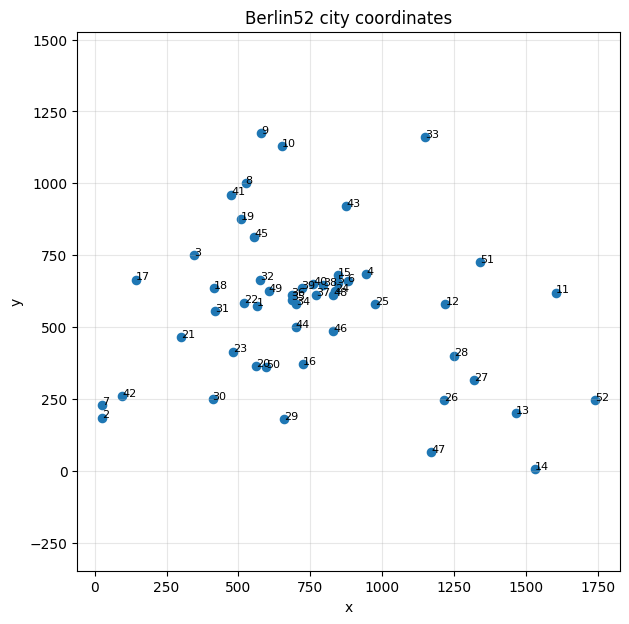

In [7]:
plt.figure(figsize=(7, 7))

plt.scatter(coords[:, 0], coords[:, 1], s=35)

for idx in range(N):
    x = coords[idx, 0].item()
    y = coords[idx, 1].item()
    plt.text(x, y, str(idx + 1), fontsize=8)

plt.title("Berlin52 city coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Move distance matrices to device
D = D.to(device)
D_raw = D_raw.to(device)
coords_device = coords.to(device)

# Local fields:
# h[r, t, a]
# r = replica
# t = tour slot
# a = city assigned to slot t
h = 1e-3 * torch.randn(
    N_REPLICAS,
    N,
    N,
    device=device,
    dtype=dtype,
    requires_grad=True
)

# Slot-wise categorical probabilities:
# P[r, t, a] = probability that city a is placed at slot t
P = torch.softmax(h, dim=2)

print("h shape:", h.shape)
print("P shape:", P.shape)

# Check slot normalization: sum_a P[r,t,a] = 1
slot_sums = P.sum(dim=2)

print("\nSlot sums shape:", slot_sums.shape)
print("Slot sums min:", slot_sums.min().item())
print("Slot sums max:", slot_sums.max().item())
print("Slot sums mean:", slot_sums.mean().item())

# City usage: sum_t P[r,t,a], should initially be near 1 because P ~ uniform
city_usage = P.sum(dim=1)

print("\nCity usage shape:", city_usage.shape)
print("City usage min:", city_usage.min().item())
print("City usage max:", city_usage.max().item())
print("City usage mean:", city_usage.mean().item())

# Expected uniform entropy per replica: N log N
S_uniform = N * math.log(N)
print("\nExpected initial entropy near N log N:", S_uniform)

h shape: torch.Size([128, 52, 52])
P shape: torch.Size([128, 52, 52])

Slot sums shape: torch.Size([128, 52])
Slot sums min: 0.9999998211860657
Slot sums max: 1.000000238418579
Slot sums mean: 1.0

City usage shape: torch.Size([128, 52])
City usage min: 0.9994739890098572
City usage max: 1.00059175491333
City usage mean: 1.0

Expected initial entropy near N log N: 205.46467336623422


### Define free energy terms

In [9]:
def expected_tour_length(P, D):

    # cyclic next slot: t -> t+1, and final slot -> first slot
    P_next = torch.roll(P, shifts=-1, dims=1)

    # U[r] = sum_t sum_a sum_b P[r,t,a] D[a,b] P[r,t+1,b]
    U_tour = torch.einsum("rta,ab,rtb->r", P, D, P_next)

    return U_tour


def city_penalty(P, lambda_city):

    city_usage = P.sum(dim=1)  # [R, N]

    penalty = lambda_city * ((city_usage - 1.0) ** 2).sum(dim=1)

    return penalty, city_usage


def entropy_term(P):
    
    eps = 1e-12
    P_safe = P.clamp_min(eps)

    S = -(P_safe * torch.log(P_safe)).sum(dim=(1, 2))

    return S


def free_energy_tsp(P, D, beta, lambda_city):

    U_tour = expected_tour_length(P, D)
    U_city, city_usage = city_penalty(P, lambda_city)
    S = entropy_term(P)

    F = U_tour + U_city - S / beta

    return F, U_tour, U_city, S, city_usage

In [10]:
beta = torch.tensor(BETA_MIN, device=device, dtype=dtype)

F, U_tour, U_city, S, city_usage = free_energy_tsp(
    P=P,
    D=D,
    beta=beta,
    lambda_city=LAMBDA_CITY
)

print("Shapes:")
print("F shape          :", F.shape)
print("U_tour shape     :", U_tour.shape)
print("U_city shape     :", U_city.shape)
print("S shape          :", S.shape)
print("city_usage shape :", city_usage.shape)

Shapes:
F shape          : torch.Size([128])
U_tour shape     : torch.Size([128])
U_city shape     : torch.Size([128])
S shape          : torch.Size([128])
city_usage shape : torch.Size([128, 52])


### Define permutation decoder AND hard set discrete tour length

In [11]:
def decode_tour(P_single):
    """
    Decode one replica's soft assignment matrix into a valid TSP tour.

    P_single shape: [N, N]
        P_single[t, a] = probability that city a is placed at slot t

    Returns:
        tour_1based: list of length N
            tour_1based[t] = TSPLIB city label assigned to slot t
            City labels are 1, 2, ..., N
    """

    P_np = P_single.detach().cpu().numpy()

    # Maximize sum_t P[t, city_t].
    # scipy solves minimization, so use -P.
    slot_ind, city_ind = linear_sum_assignment(-P_np)

    tour_internal = [None] * N

    for slot, city in zip(slot_ind, city_ind):
        tour_internal[slot] = int(city)

    # Convert to TSPLIB 1-based city labels for all external use.
    tour_1based = [city + 1 for city in tour_internal]

    return tour_1based


def discrete_tour_length(tour_1based, D_raw):
    """
    Compute actual raw TSP tour length.

    Input tour uses TSPLIB 1-based city labels.
    Distance lookup internally converts labels back to tensor indices.
    """

    D_raw_cpu = D_raw.detach().cpu()

    length = 0.0

    for t in range(N):
        a = tour_1based[t] - 1
        b = tour_1based[(t + 1) % N] - 1
        length += D_raw_cpu[a, b].item()

    return length

In [12]:
test_replica = torch.argmin(F).item()

test_tour = decode_tour(P[test_replica])
test_length = discrete_tour_length(test_tour, D_raw)

print("Test replica:", test_replica)
print("Decoded tour length:", len(test_tour))
print("Unique cities:", len(set(test_tour)))
print("Valid tour:", len(set(test_tour)) == N)

print("\nInitial decoded raw tour length:", test_length)

print("\nDecoded tour in TSPLIB 1-based city labels:")
print(test_tour)

Test replica: 119
Decoded tour length: 52
Unique cities: 52
Valid tour: True

Initial decoded raw tour length: 30788.0

Decoded tour in TSPLIB 1-based city labels:
[17, 26, 5, 18, 36, 1, 15, 24, 25, 46, 10, 34, 30, 48, 35, 51, 12, 42, 43, 52, 21, 2, 49, 44, 47, 6, 20, 33, 16, 4, 3, 31, 14, 45, 50, 22, 40, 13, 27, 39, 29, 28, 8, 32, 37, 38, 9, 7, 41, 23, 11, 19]


### Beta annealing schedule

In [13]:
SCHEDULE_TYPE = "linear_temperature"

# ------------------------------------------------------------
# Option 1: Linear temperature cooling
# ------------------------------------------------------------

T_MAX = 1.0 / BETA_MIN
T_MIN = 1.0 / BETA_MAX

temperature_schedule_linear = torch.linspace(
    T_MAX,
    T_MIN,
    N_STEPS,
    device=device,
    dtype=dtype
)

beta_schedule_linearT = 1.0 / temperature_schedule_linear

# ------------------------------------------------------------
# Option 2: Exponential beta annealing
# ------------------------------------------------------------

beta_schedule_exp = torch.exp(
    torch.linspace(
        math.log(BETA_MIN),
        math.log(BETA_MAX),
        N_STEPS,
        device=device,
        dtype=dtype
    )
)

temperature_schedule_exp = 1.0 / beta_schedule_exp

# ------------------------------------------------------------
# Select active schedule
# ------------------------------------------------------------

if SCHEDULE_TYPE == "linear_temperature":
    temperature_schedule = temperature_schedule_linear
    beta_schedule = beta_schedule_linearT

elif SCHEDULE_TYPE == "exponential_beta":
    temperature_schedule = temperature_schedule_exp
    beta_schedule = beta_schedule_exp

else:
    raise ValueError(f"Unknown SCHEDULE_TYPE: {SCHEDULE_TYPE}")

print("Selected schedule:", SCHEDULE_TYPE)

print("\nTemperature schedule shape:", temperature_schedule.shape)
print("T start:", temperature_schedule[0].item())
print("T end  :", temperature_schedule[-1].item())

print("\nBeta schedule shape:", beta_schedule.shape)
print("beta start:", beta_schedule[0].item())
print("beta end  :", beta_schedule[-1].item())

print("\nFirst 5 temperatures:")
print(temperature_schedule[:5].detach().cpu().numpy())

print("\nLast 5 temperatures:")
print(temperature_schedule[-5:].detach().cpu().numpy())

print("\nFirst 5 beta values:")
print(beta_schedule[:5].detach().cpu().numpy())

print("\nLast 5 beta values:")
print(beta_schedule[-5:].detach().cpu().numpy())

Selected schedule: linear_temperature

Temperature schedule shape: torch.Size([3000])
T start: 2.0
T end  : 0.020000100135803223

Beta schedule shape: torch.Size([3000])
beta start: 0.5
beta end  : 49.99974822998047

First 5 temperatures:
[2.        1.9993398 1.9986795 1.9980193 1.9973592]

Last 5 temperatures:
[0.02264094 0.02198076 0.02132058 0.02066028 0.0200001 ]

First 5 beta values:
[0.5       0.5001651 0.5003303 0.5004957 0.5006611]

Last 5 beta values:
[44.16777  45.494328 46.903034 48.40205  49.99975 ]


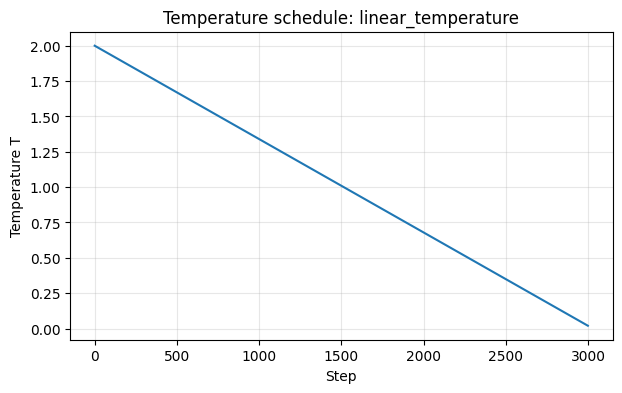

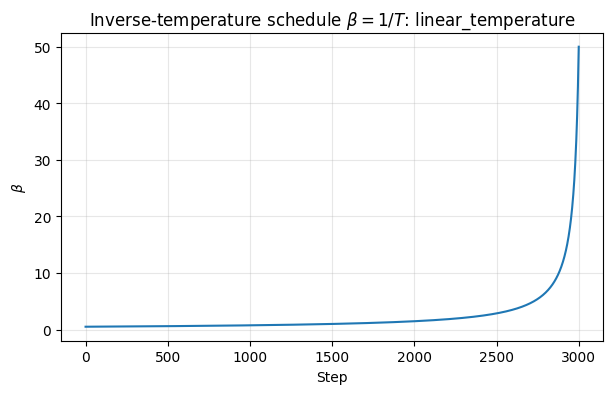

In [14]:
# ------------------------------------------------------------
# Plot active temperature schedule
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(temperature_schedule.detach().cpu().numpy())
plt.title(f"Temperature schedule: {SCHEDULE_TYPE}")
plt.xlabel("Step")
plt.ylabel("Temperature T")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot active beta schedule
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(beta_schedule.detach().cpu().numpy())
plt.title(rf"Inverse-temperature schedule $\beta = 1/T$: {SCHEDULE_TYPE}")
plt.xlabel("Step")
plt.ylabel(r"$\beta$")
plt.grid(True, alpha=0.3)
plt.show()

### Test 1

In [15]:
# Make sure h is a leaf tensor before giving it to Adam
h = h.detach().clone().requires_grad_(True)

optimizer = torch.optim.Adam([h], lr=LR)

LOG_EVERY = 100
BERLIN52_OPTIMUM = 7542

logs = []

start_time = time.time()

iterator = range(N_STEPS)
if tqdm is not None:
    iterator = tqdm(iterator)

best_seen_length = float("inf")
best_seen_tour = None
best_seen_replica = None

for step in iterator:
    beta = beta_schedule[step]

    optimizer.zero_grad()

    # Current soft assignment probabilities
    P = torch.softmax(h, dim=2)

    # FEM objective
    F, U_tour, U_city, S, city_usage = free_energy_tsp(
        P=P,
        D=D,
        beta=beta,
        lambda_city=LAMBDA_CITY
    )

    # Optimize average free energy over replicas
    loss = F.mean()

    loss.backward()
    optimizer.step()

    # --------------------------------------------------------
    # Logging and decoding
    # --------------------------------------------------------
    if step % LOG_EVERY == 0 or step == N_STEPS - 1:
        with torch.no_grad():
            P_eval = torch.softmax(h, dim=2)

            F_eval, U_eval, U_city_eval, S_eval, city_usage_eval = free_energy_tsp(
                P=P_eval,
                D=D,
                beta=beta,
                lambda_city=LAMBDA_CITY
            )

            # Decode all replicas and choose best raw discrete tour
            current_best_length = float("inf")
            current_best_tour = None
            current_best_replica = None

            for r in range(N_REPLICAS):
                tour_r = decode_tour(P_eval[r])              # 1-based TSPLIB tour
                length_r = discrete_tour_length(tour_r, D_raw)

                if length_r < current_best_length:
                    current_best_length = length_r
                    current_best_tour = tour_r
                    current_best_replica = r

            # Update global best
            if current_best_length < best_seen_length:
                best_seen_length = current_best_length
                best_seen_tour = current_best_tour
                best_seen_replica = current_best_replica

            city_violation = torch.abs(city_usage_eval - 1.0)

            gap_percent = 100.0 * (best_seen_length - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM

            log_row = {
                "step": step,
                "schedule_type": SCHEDULE_TYPE,
                "beta": beta.item(),
                "temperature": (1.0 / beta).item(),
                "loss": loss.item(),
                "F_min": F_eval.min().item(),
                "F_mean": F_eval.mean().item(),
                "U_tour_min": U_eval.min().item(),
                "U_tour_mean": U_eval.mean().item(),
                "U_city_min": U_city_eval.min().item(),
                "U_city_mean": U_city_eval.mean().item(),
                "S_mean": S_eval.mean().item(),
                "city_violation_mean": city_violation.mean().item(),
                "city_violation_max": city_violation.max().item(),
                "current_best_length": current_best_length,
                "current_best_replica": current_best_replica,
                "best_seen_length": best_seen_length,
                "best_seen_replica": best_seen_replica,
                "gap_percent": gap_percent,
                "elapsed_sec": time.time() - start_time,
            }

            logs.append(log_row)

            print(
                f"step {step:5d} | "
                f"T {(1.0 / beta).item():8.4f} | "
                f"beta {beta.item():8.4f} | "
                f"F_min {F_eval.min().item():10.4f} | "
                f"U_min {U_eval.min().item():8.4f} | "
                f"S_mean {S_eval.mean().item():8.4f} | "
                f"best raw {best_seen_length:8.1f} | "
                f"gap {gap_percent:7.2f}%"
            )

logs_df = pd.DataFrame(logs)

# Final probabilities after training
P = torch.softmax(h, dim=2)

print("\nTraining finished")
print("Schedule type:", SCHEDULE_TYPE)
print("Best raw tour length seen:", best_seen_length)
print("Best replica:", best_seen_replica)
print("Gap vs Berlin52 optimum 7542:", 100.0 * (best_seen_length - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM, "%")

print("\nBest tour in TSPLIB 1-based city labels:")
print(best_seen_tour)

step     0 | T   2.0000 | beta   0.5000 | F_min  -393.8687 | U_min  17.0063 | S_mean 205.4621 | best raw  26085.0 | gap  245.86%
step   100 | T   1.9340 | beta   0.5171 | F_min  -380.3191 | U_min  16.9933 | S_mean 205.4623 | best raw  25809.0 | gap  242.20%
step   200 | T   1.8680 | beta   0.5353 | F_min  -366.7541 | U_min  16.9930 | S_mean 205.4623 | best raw  25519.0 | gap  238.36%
step   300 | T   1.8019 | beta   0.5550 | F_min  -353.1890 | U_min  16.9927 | S_mean 205.4623 | best raw  24387.0 | gap  223.35%
step   400 | T   1.7359 | beta   0.5761 | F_min  -339.6240 | U_min  16.9924 | S_mean 205.4622 | best raw  24387.0 | gap  223.35%
step   500 | T   1.6699 | beta   0.5988 | F_min  -326.0589 | U_min  16.9921 | S_mean 205.4622 | best raw  24387.0 | gap  223.35%
step   600 | T   1.6039 | beta   0.6235 | F_min  -312.4939 | U_min  16.9918 | S_mean 205.4622 | best raw  24387.0 | gap  223.35%
step   700 | T   1.5378 | beta   0.6503 | F_min  -298.9289 | U_min  16.9914 | S_mean 205.4622 | b

In [16]:
BERLIN52_OPTIMUM = 7542

with torch.no_grad():
    # Final trained soft probabilities
    P_final = torch.softmax(h, dim=2)

    # Final FEM quantities at final beta
    beta_final = beta_schedule[-1]

    F_final, U_tour_final, U_city_final, S_final, city_usage_final = free_energy_tsp(
        P=P_final,
        D=D,
        beta=beta_final,
        lambda_city=LAMBDA_CITY
    )

    inference_rows = []

    for r in range(N_REPLICAS):
        tour_r = decode_tour(P_final[r])              # TSPLIB 1-based tour
        length_r = discrete_tour_length(tour_r, D_raw)

        valid_r = (len(tour_r) == N) and (len(set(tour_r)) == N)

        inference_rows.append({
            "replica": r,
            "raw_tour_length": length_r,
            "gap_percent": 100.0 * (length_r - BERLIN52_OPTIMUM) / BERLIN52_OPTIMUM,
            "valid_tour": valid_r,
            "F": F_final[r].item(),
            "U_tour_normalized": U_tour_final[r].item(),
            "U_city": U_city_final[r].item(),
            "entropy": S_final[r].item(),
            "tour_1based": tour_r,
        })

inference_df = pd.DataFrame(inference_rows)
inference_df = inference_df.sort_values("raw_tour_length").reset_index(drop=True)

best_row = inference_df.iloc[0]

best_final_replica = int(best_row["replica"])
best_final_length = float(best_row["raw_tour_length"])
best_final_gap = float(best_row["gap_percent"])
best_final_tour = best_row["tour_1based"]

print("Inference finished")
print("Schedule type:", SCHEDULE_TYPE)
print("Final beta:", beta_final.item())
print("Final temperature:", (1.0 / beta_final).item())

print("\nBest final replica:", best_final_replica)
print("Best final raw tour length:", best_final_length)
print("Gap vs Berlin52 optimum 7542:", best_final_gap, "%")
print("Valid tour:", bool(best_row["valid_tour"]))

Inference finished
Schedule type: linear_temperature
Final beta: 49.99974822998047
Final temperature: 0.020000100135803223

Best final replica: 15
Best final raw tour length: 9410.0
Gap vs Berlin52 optimum 7542: 24.76796605674887 %
Valid tour: True


In [17]:
print("\nBest final tour in TSPLIB 1-based city labels:")
print(best_final_tour)

print("\nTop 10 replicas by decoded raw tour length:")
display(
    inference_df[
        [
            "replica",
            "raw_tour_length",
            "gap_percent",
            "valid_tour",
            "F",
            "U_tour_normalized",
            "U_city",
            "entropy",
        ]
    ].head(10)
)


Best final tour in TSPLIB 1-based city labels:
[8, 9, 10, 32, 36, 35, 34, 39, 40, 37, 38, 24, 5, 6, 43, 33, 51, 11, 27, 47, 52, 14, 13, 26, 28, 12, 25, 4, 15, 48, 46, 44, 16, 49, 1, 50, 20, 29, 30, 7, 2, 42, 17, 21, 23, 31, 18, 22, 3, 45, 19, 41]

Top 10 replicas by decoded raw tour length:


,replica,raw_tour_length,gap_percent,valid_tour,F,U_tour_normalized,U_city,entropy
0,15,9410.0,24.767966,True,5.148619,7.788723,0.007314,132.370209
1,95,9484.0,25.749138,True,5.525496,8.290098,0.007610,138.609894
2,72,9528.0,26.332538,True,5.117934,7.731543,0.006712,131.015366
3,108,9660.0,28.082737,True,5.269552,7.921353,0.007541,132.966431
4,109,9664.0,28.135773,True,5.602025,8.377234,0.007683,139.143860
5,122,9698.0,28.586582,True,4.885281,7.412678,0.007082,126.723320
6,123,9715.0,28.811986,True,5.000662,7.569149,0.006721,128.759735
7,57,9764.0,29.461681,True,5.451140,8.172696,0.007211,136.437622
8,55,9837.0,30.429594,True,5.000882,7.579031,0.007025,129.258041
9,96,9847.0,30.562185,True,5.314783,8.009394,0.007656,135.112671


In [18]:
opt_tour_path = Path("berlin52.opt.tour.gz")

opt_tour = []
reading_tour = False

with gzip.open(opt_tour_path, "rt") as f:
    for line in f:
        line = line.strip()

        if line == "" or line == "EOF":
            continue

        if line == "TOUR_SECTION":
            reading_tour = True
            continue

        if reading_tour:
            city = int(line)

            if city == -1:
                break

            opt_tour.append(city)   # already TSPLIB 1-based

opt_length = discrete_tour_length(opt_tour, D_raw)

print("Loaded optimal tour from:", opt_tour_path)
print("Optimal tour length:", len(opt_tour))
print("Unique cities:", len(set(opt_tour)))
print("Valid optimal tour:", len(opt_tour) == N and len(set(opt_tour)) == N)

print("\nOptimal tour raw length from D_raw:", opt_length)
print("Known Berlin52 optimum:", BERLIN52_OPTIMUM)

print("\nBest FEM final raw tour length:", best_final_length)
print("Gap vs opt tour length:", 100.0 * (best_final_length - opt_length) / opt_length, "%")

print("\nOptimal tour in TSPLIB 1-based city labels:")
print(opt_tour)

Loaded optimal tour from: berlin52.opt.tour.gz
Optimal tour length: 52
Unique cities: 52
Valid optimal tour: True

Optimal tour raw length from D_raw: 7542.0
Known Berlin52 optimum: 7542

Best FEM final raw tour length: 9410.0
Gap vs opt tour length: 24.76796605674887 %

Optimal tour in TSPLIB 1-based city labels:
[1, 49, 32, 45, 19, 41, 8, 9, 10, 43, 33, 51, 11, 52, 14, 13, 47, 26, 27, 28, 12, 25, 4, 6, 15, 5, 24, 48, 38, 37, 40, 39, 36, 35, 34, 44, 46, 16, 29, 50, 20, 23, 30, 2, 7, 42, 21, 17, 3, 18, 31, 22]
